# Data Mining Course Project


## Dataset Description

This dataset contains detailed information about used cars listed for sale, including technical specifications, ownership history, and pricing information. Each record represents a single car with attributes such as manufacturing year, mileage driven, fuel type, transmission type, engine power, and selling price.

The dataset includes both numerical and categorical features, making it suitable for data preprocessing, feature engineering, clustering, regression, and classification tasks. Some key attributes include:

- **name**: Car model and brand  
- **year**: Manufacturing year  
- **selling_price**: Target variable representing the price of the car  
- **km_driven**: Total kilometers driven  
- **fuel**: Fuel type (Diesel, Petrol, etc.)  
- **seller_type**: Individual or Dealer  
- **transmission**: Manual or Automatic  
- **owner**: Ownership history  
- **mileage, engine, max_power, torque**: Technical specifications  
- **seats**: Number of seats in the car  

---

## Source

The dataset is publicly available on Kaggle:

- Platform: Kaggle  
- Dataset: Vehicle Dataset from CarDekho  
- Link: https://www.kaggle.com/datasets/nehalbirla/vehicle-dataset-from-cardekho  

---

## Domain Motivation

The used car market is a highly dynamic domain where pricing depends on multiple factors such as vehicle condition, age, mileage, and technical specifications. Accurately predicting car prices is important for buyers, sellers, and dealers to make informed decisions.

This dataset is motivated by real-world automotive resale markets and is particularly useful for:

- Understanding factors affecting car prices  
- Building predictive models for price estimation  
- Segmenting cars into different market categories (budget, mid-range, premium)  
- Supporting business decision-making in automotive sales platforms  

The dataset is also suitable for machine learning applications in regression, clustering, and feature selection, making it a strong candidate for data science projects.

---

##### Importing libraries

In [3]:
import numpy as np
import pandas as pd
import math
import random
import warnings
# ===============================
import matplotlib.pyplot as plt
import seaborn as sns
# ===============================
from sklearn.preprocessing import StandardScaler , MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import sklearn.linear_model
# ===============================
from sklearn.metrics import r2_score, silhouette_score
# ===============================
from sklearn_extra.cluster import KMedoids
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch
# ===============================
from sklearn.decomposition import PCA
# ===============================
import skfuzzy as fuzz
from skfuzzy import control as ctrl

#### loading the data

In [4]:
df = pd.read_csv(r"data/Car details v3.csv")
df.head(4)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0


---

## Data Exploration


In [5]:
df.info()
print('*'*50)
print("Table shape :",df.shape)

<class 'pandas.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   str    
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   str    
 5   seller_type    8128 non-null   str    
 6   transmission   8128 non-null   str    
 7   owner          8128 non-null   str    
 8   mileage        7907 non-null   str    
 9   engine         7907 non-null   str    
 10  max_power      7913 non-null   str    
 11  torque         7906 non-null   str    
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), str(9)
memory usage: 825.6 KB
**************************************************
Table shape : (8128, 13)


In [6]:
print("Number of ? values :",df.isin(['?']).sum().sum())
print("------------------------------")
print("Number of Null values in each col :")
print(df.isna().sum())

Number of ? values : 0
------------------------------
Number of Null values in each col :
name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          221
engine           221
max_power        215
torque           222
seats            221
dtype: int64


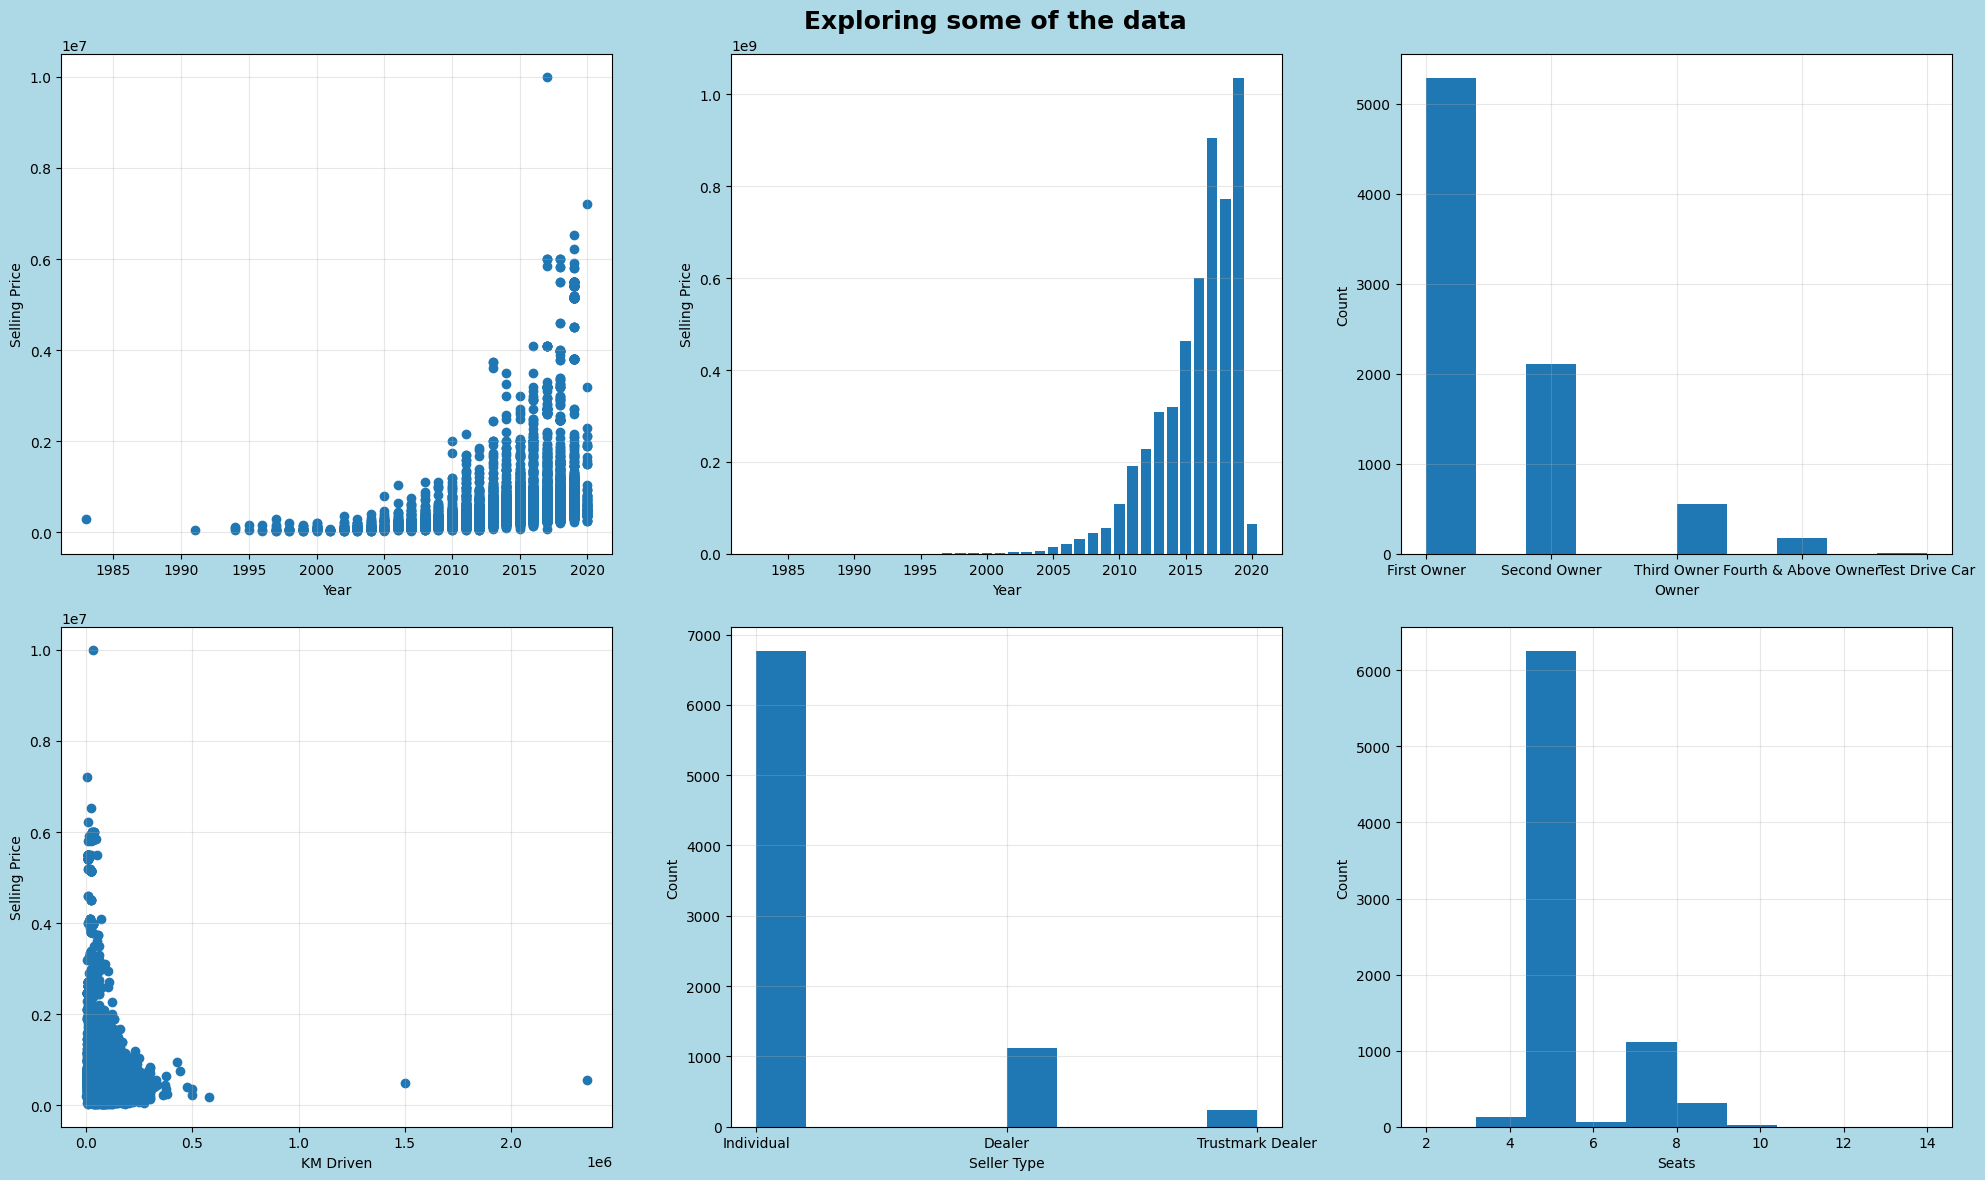

In [7]:
fig, axes = plt.subplots(2,3,figsize=(20,12))

fig.patch.set_facecolor('lightblue')

axes[0,0].scatter(df['year'], df['selling_price'])
axes[0,0].set_xlabel('Year')
axes[0,0].set_ylabel('Selling Price')
axes[0,0].grid(alpha=0.3)

axes[1,0].scatter(df['km_driven'], df['selling_price'])
axes[1,0].set_xlabel('KM Driven')
axes[1,0].set_ylabel('Selling Price')
axes[1,0].grid(alpha=0.3)

grouped = df.groupby('year')['selling_price'].sum()
axes[0,1].bar(grouped.index, grouped.values)
axes[0,1].set_xlabel('Year')
axes[0,1].set_ylabel('Selling Price')
axes[0,1].grid(axis='y', alpha=0.3)

axes[1,1].hist(df['seller_type'])
axes[1,1].set_xlabel('Seller Type')
axes[1,1].set_ylabel('Count')
axes[1,1].grid(alpha=0.3)

axes[0,2].hist(df['owner'])
axes[0,2].set_xlabel('Owner')
axes[0,2].set_ylabel('Count')
axes[0,2].grid(alpha=0.3)

axes[1,2].hist(df['seats'])
axes[1,2].set_xlabel('Seats')
axes[1,2].set_ylabel('Count')
axes[1,2].grid(alpha=0.3)

fig.suptitle('Exploring some of the data', fontsize=18, fontweight='bold')

plt.tight_layout()

plt.show()

- Age and Price
Newer is better: Newer cars (2015–2019) are much more expensive than old cars.

Prices started to go up a lot after the year 2010.

- Mileage (KM Driven)
Low KM = High Price: Cars that haven't driven many kilometers sell for a lot of money.

- Number of Owners
First Owner is king: Most cars for sale have only had one owner.

People rarely buy or sell cars that have had 3 or 4 owners.

- Who is selling?
Person to Person: Most cars are sold by individuals (the owners), not by car dealers or shops.

- Number of Seats
5-Seaters are the favorite: Almost every car in the data has 5 seats.

Big cars (7 or 8 seats) are very rare.

- Market Growth
The car market became very big and busy between 2015 and 2019.

---

## Data cleaning

In [8]:
print("Number of duplicate rows :",df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("Number of duplicate rows after dropping duplicates :",df.duplicated().sum())

Number of duplicate rows : 1202
Number of duplicate rows after dropping duplicates : 0


In [9]:
df['brand_name'] = df['name'].str.extract(r'(\w+) ')
df['brand_model'] = df['name'].str.extract(r'\w+ (.+)')
df['mileage_unit'] = df['mileage'].str.extract(r' (.+)')
df['mileage_value'] = df['mileage'].str.extract('(\d+\.\d+)')
df['engine by CC'] = df['engine'].str.extract(r'(\d+)')
df['max_power by bhp'] = df['max_power'].str.extract(r'(\d+\.?\d*)')
df['torque_value'] = df['torque'].str.extract(r'([\d\.]+)')
df.drop(columns=['name','mileage','engine','max_power','torque','brand_model'],inplace=True)
df[['selling_price','km_driven','seats','mileage_value','engine by CC','max_power by bhp','torque_value']] = df[['selling_price','km_driven','seats','mileage_value','engine by CC','max_power by bhp','torque_value']].astype('float')

*************************************************************** 
*********************************

In [10]:
df['mileage_unit'] = df['mileage_unit'].fillna(df['mileage_unit'].mode()[0])
df['seats'] = df['seats'].fillna(df['seats'].mode()[0])

###################################################################
df['engine by CC'] = df['engine by CC'].fillna(df['engine by CC'].median())
df['max_power by bhp'] = df['max_power by bhp'].fillna(df['max_power by bhp'].median())
df['mileage_value'] = df['mileage_value'].fillna(df['mileage_value'].median())
df['torque_value'] = df['torque_value'].fillna(df['torque_value'].median())

####################################################################
df['car_age'] = 2026 - df['year']
df['power_density'] = df['max_power by bhp'] / df['engine by CC']
df['km_per_year'] = df['km_driven'] / (2026 - df['year'] + 1)

####################################################################
df.drop(columns=['year'], inplace=True)

df.isna().sum()

selling_price       0
km_driven           0
fuel                0
seller_type         0
transmission        0
owner               0
seats               0
brand_name          0
mileage_unit        0
mileage_value       0
engine by CC        0
max_power by bhp    0
torque_value        0
car_age             0
power_density       0
km_per_year         0
dtype: int64

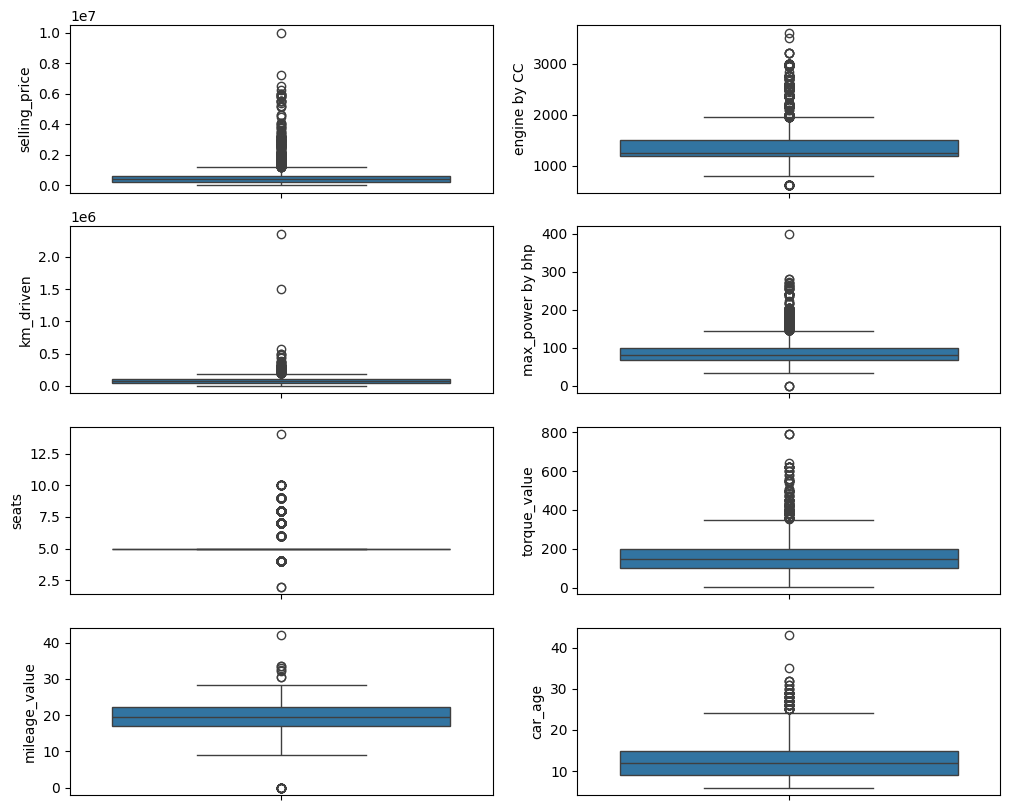

Number of rows before outlier removal: 6926
Number of rows after outlier removal: 5256


In [11]:
fig,axs=plt.subplots(4,2,figsize=(12,10))
sns.boxplot(df['selling_price'],ax=axs[0,0])
sns.boxplot(df['km_driven'],ax=axs[1,0])
sns.boxplot(df['seats'],ax=axs[2,0])
sns.boxplot(df['mileage_value'],ax=axs[3,0])
sns.boxplot(df['engine by CC'],ax=axs[0,1])
sns.boxplot(df['max_power by bhp'],ax=axs[1,1])
sns.boxplot(df['torque_value'],ax=axs[2,1])
sns.boxplot(df['car_age'],ax=axs[3,1])
plt.show()

print("Number of rows before outlier removal:", df.shape[0])

def remove_outliers(df, col):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5* iqr
    df_cleaned = df[(df[col] >= lower) & (df[col] <= upper)]
    return df_cleaned

df = remove_outliers(df, 'selling_price')
df = remove_outliers(df, 'km_driven')
df = remove_outliers(df, 'engine by CC')
df = remove_outliers(df, 'max_power by bhp')
df = remove_outliers(df, 'mileage_value')
df = remove_outliers(df, 'torque_value')
df = remove_outliers(df, 'car_age')

print("Number of rows after outlier removal:", df.shape[0])

In [12]:
df_without_scaling = df.copy()
scaler = MinMaxScaler()
numeric_cols = [ 'km_driven', 'seats', 'mileage_value', 'engine by CC', 'max_power by bhp', 'torque_value', 'car_age', 'power_density', 'km_per_year']
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

df = pd.get_dummies(df,columns=['fuel','owner','brand_name','seller_type','mileage_unit','transmission'],drop_first=True,dtype='int')
df.head()

,selling_price,km_driven,seats,mileage_value,engine by CC,max_power by bhp,torque_value,car_age,power_density,km_per_year,...,brand_name_Nissan,brand_name_Renault,brand_name_Skoda,brand_name_Tata,brand_name_Toyota,brand_name_Volkswagen,seller_type_Individual,seller_type_Trustmark Dealer,mileage_unit_kmpl,transmission_Manual
0,450000.0,0.765788,0.166667,0.691358,0.393939,0.453488,0.626232,0.333333,0.296434,0.647974,...,0,0,0,0,0,0,1,0,1,1
1,370000.0,0.631577,0.166667,0.551852,0.610390,0.796744,0.830105,0.333333,0.412847,0.534411,...,0,0,1,0,0,0,1,0,1,1
2,158000.0,0.736841,0.166667,0.339506,0.609524,0.500000,0.023785,0.777778,0.211109,0.385963,...,0,0,0,0,0,0,1,0,1,1
3,225000.0,0.668419,0.166667,0.666667,0.522078,0.639535,0.056745,0.555556,0.357842,0.432506,...,0,0,0,0,0,0,1,0,1,1
4,130000.0,0.631577,0.166667,0.240741,0.437229,0.618605,0.019708,0.722222,0.399145,0.347366,...,0,0,0,0,0,0,1,0,1,1


In [13]:
df.corr()['selling_price'].sort_values(ascending=False).head(10)

selling_price          1.000000
torque_value           0.559723
max_power by bhp       0.551799
power_density          0.422650
engine by CC           0.362209
mileage_value          0.346944
fuel_Diesel            0.292415
seats                  0.234279
brand_name_Honda       0.175664
brand_name_Mahindra    0.119351
Name: selling_price, dtype: float64

Text(0.5, 1.0, 'Correlation Heatmap')

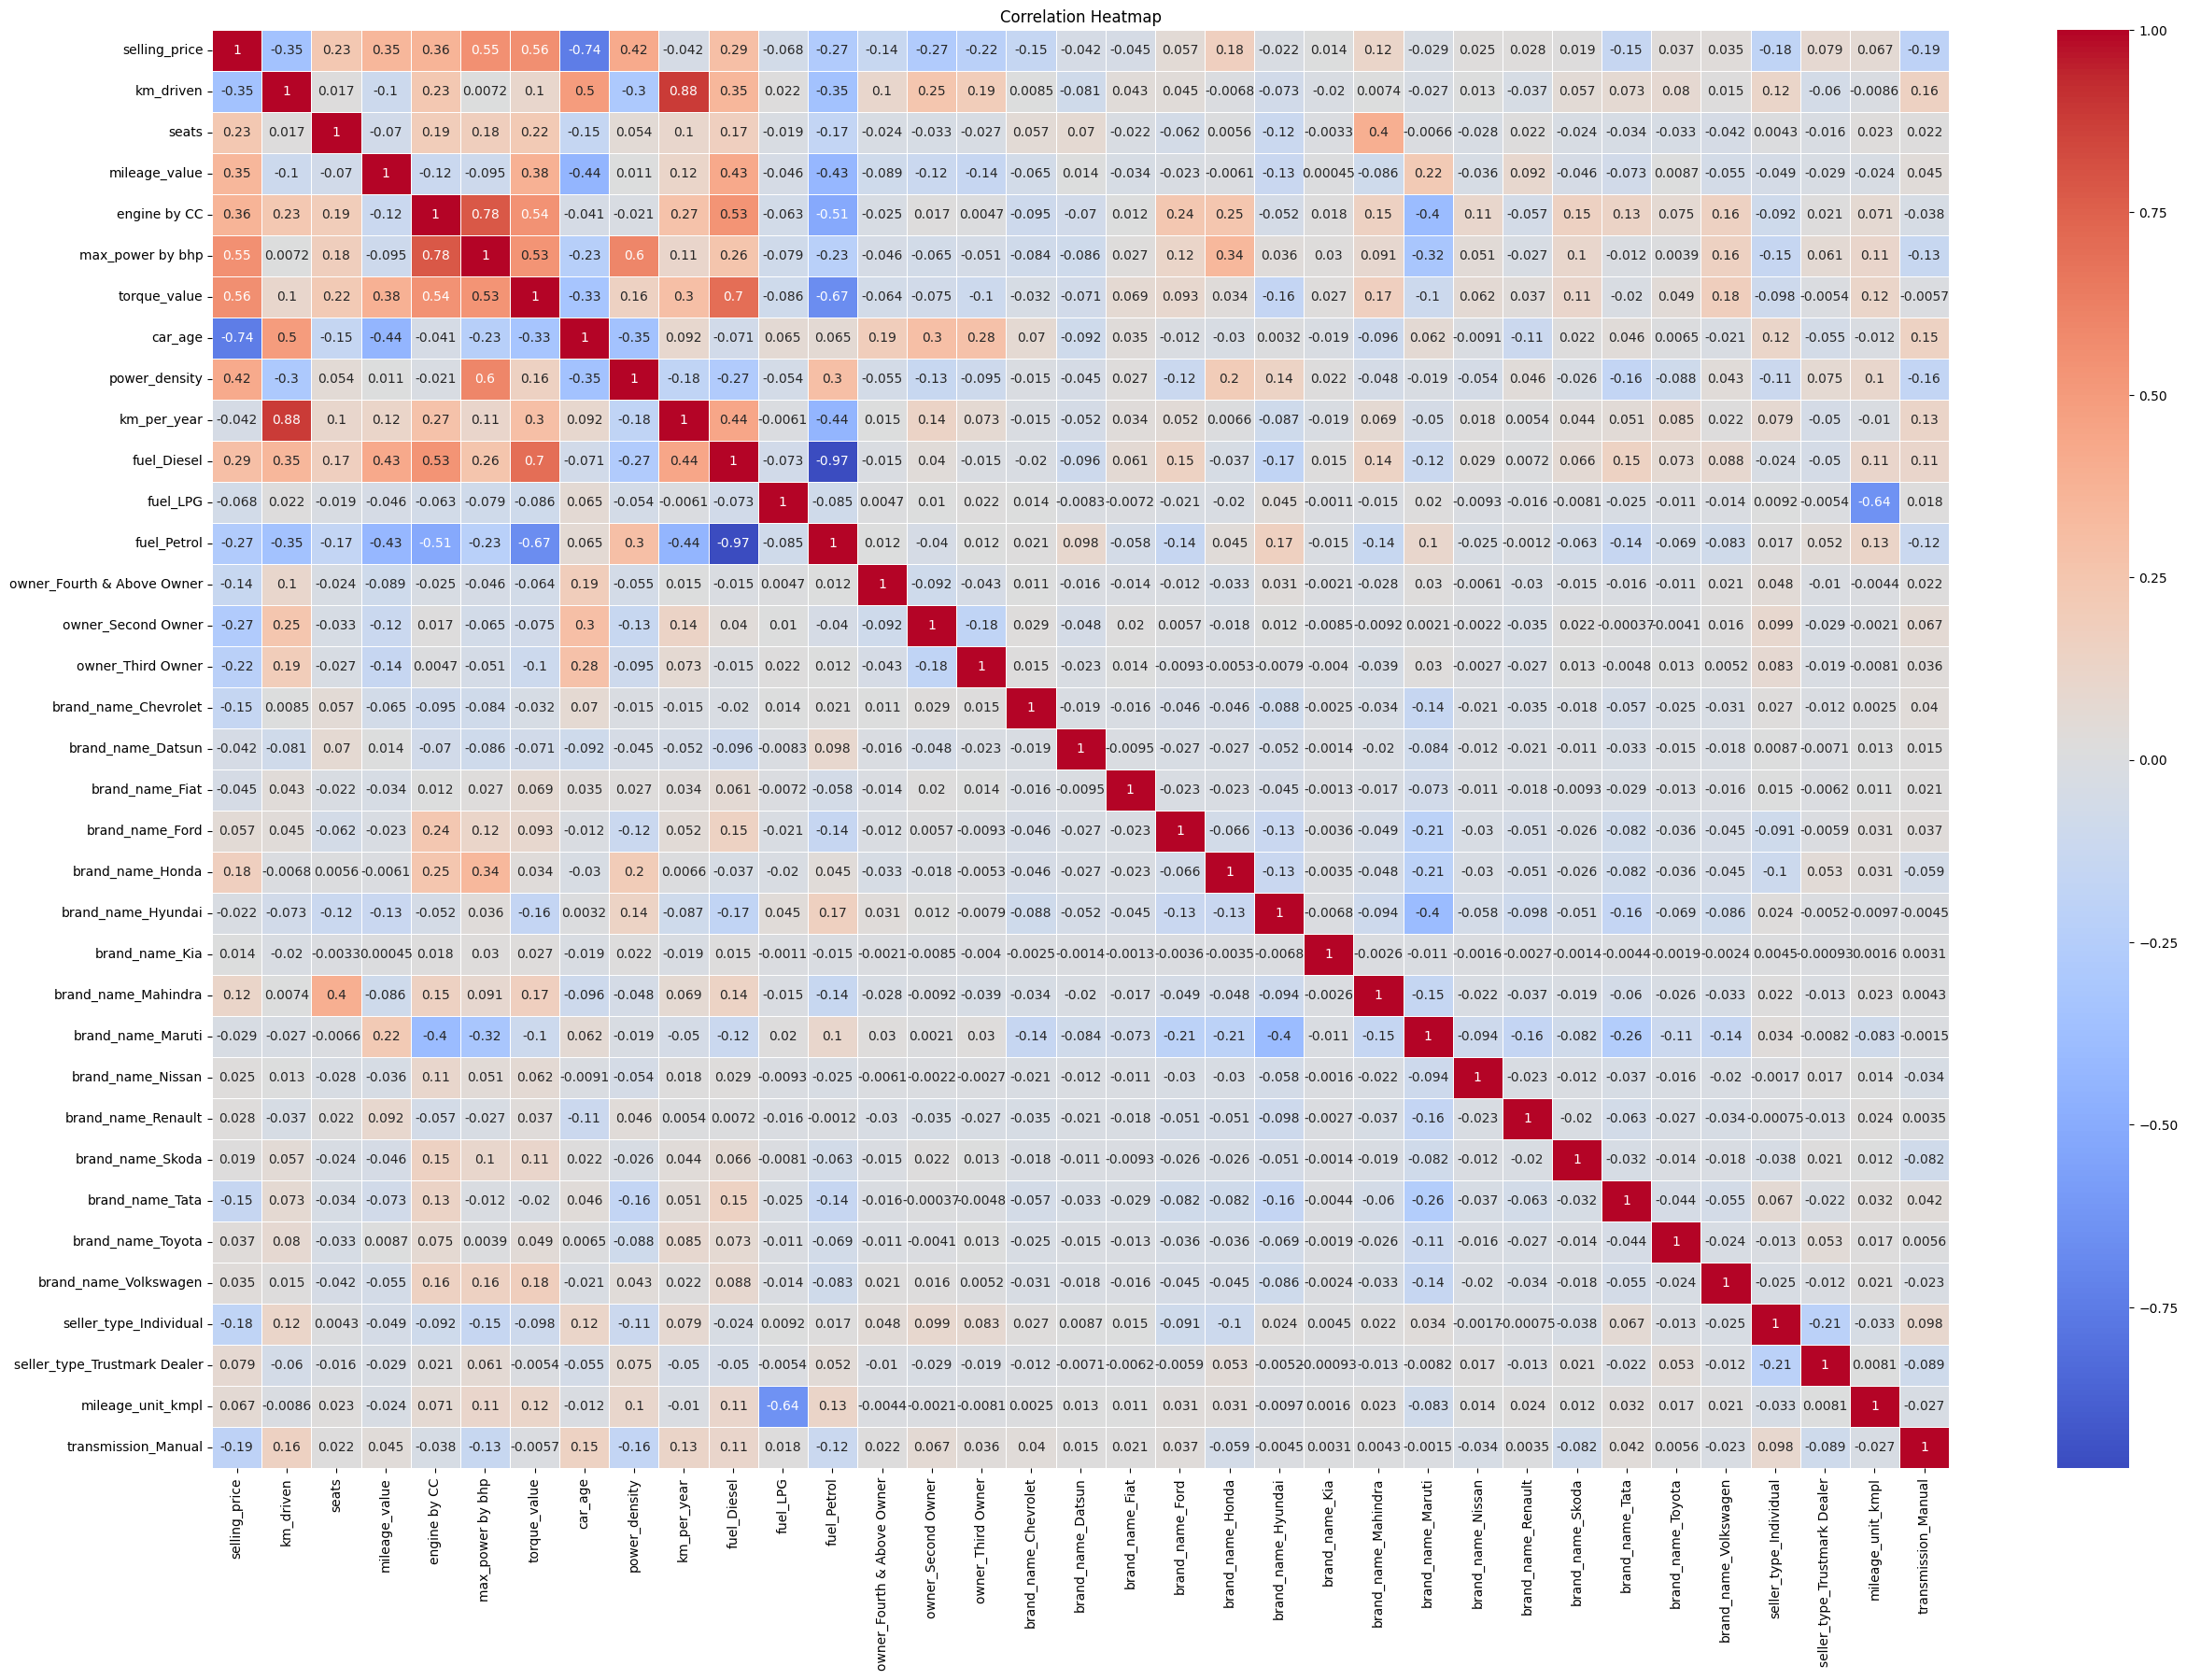

In [14]:
plt.figure(figsize=(30, 20))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')


In [15]:
bins = np.linspace(df['selling_price'].min(),df['selling_price'].max(),4)
category = ['Cheap','Moderate','Expensive']
df['price_category'] = pd.cut(df['selling_price'],bins,labels=category,include_lowest=True)

In [16]:
df['price_category'].value_counts()

price_category
Cheap        3069
Moderate     1917
Expensive     270
Name: count, dtype: int64

##########################################################################################################################################################################################################################

### PCA

In [17]:
dff = df.copy()
target_col = 'selling_price'

X = dff.drop(columns=[target_col]).select_dtypes(include=[np.number])
y = dff[target_col]

pca_full = PCA().fit(X)
n = np.argmax(np.cumsum(pca_full.explained_variance_ratio_) >= 0.95) + 1

pca = PCA(n_components=n, random_state=42)
X_pca = pca.fit_transform(X)

print(f"Original features : {X.shape[1]}")
print(f"After PCA         : {n} components")
print(f"Variance retained : {pca.explained_variance_ratio_.sum():.2%}")


df_pca = pd.DataFrame(X_pca,columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])
df_pca[target_col] = y.values

Original features : 34
After PCA         : 19 components
Variance retained : 95.65%


In [18]:
df_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,selling_price
0,0.763330,0.720592,-0.191192,0.284793,0.153430,-0.081858,0.056568,-0.068284,-0.013991,-0.246446,0.184449,-0.185802,0.171415,0.064018,-0.207428,0.019054,0.003563,-0.032581,-0.086520,450000.0
1,0.987500,-0.202178,0.680964,-0.169722,-0.180081,-0.133602,0.218873,-0.108436,0.059931,0.109838,0.164865,0.009716,0.216809,-0.058489,-0.175047,-0.099716,-0.055951,0.139580,0.066794,370000.0
2,-0.588204,-0.359392,-0.162059,-0.575729,0.670509,-1.063951,0.173676,-0.469492,-0.316631,-0.161187,-0.394067,-0.102162,-0.102409,0.164579,0.042261,0.138765,0.046987,-0.042916,-0.061525,158000.0
3,0.665071,-0.637994,-0.097669,0.720599,0.262686,-0.101092,-0.070943,-0.070460,-0.032083,-0.298573,0.071930,-0.213897,-0.029196,0.022345,0.062083,0.001535,0.003321,-0.000629,-0.164601,225000.0
4,-0.750352,0.528782,-0.065912,-0.065558,0.291281,-0.279363,-0.018479,-0.082109,0.185735,-0.336983,0.337211,-0.072944,0.097510,-0.016792,0.107539,-0.093695,-0.050865,0.045584,-0.196358,130000.0


---

## K-Medoids Clustering 

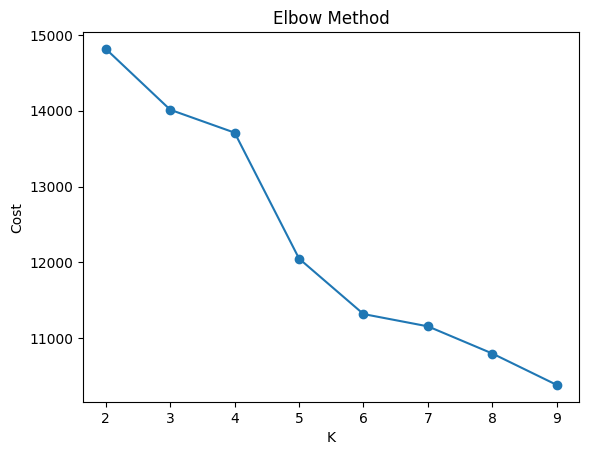

In [19]:
#  Elbow Method
inertia = []
K_range = range(2, 10)

for k in K_range:
    model = KMedoids(n_clusters=k, metric='manhattan', init='random', random_state=42)
    model.fit(df.drop(columns=['selling_price','price_category']))
    inertia.append(model.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('K')
plt.ylabel('Cost')
plt.show()

In [20]:
# Silhouette Score
for k in range(2, 10):
    model = KMedoids(n_clusters=k, metric='manhattan', init='random', random_state=42)
    labels = model.fit_predict(df.drop(columns=['selling_price','price_category']))
   
    score = silhouette_score(df.drop(columns=['selling_price','price_category']), labels)
    print(f"K={k}, Silhouette Score = {score}")

K=2, Silhouette Score = 0.2662213468515632
K=3, Silhouette Score = 0.20016482070380098
K=4, Silhouette Score = 0.13594741826093
K=5, Silhouette Score = 0.1818344450133104
K=6, Silhouette Score = 0.18745107016643
K=7, Silhouette Score = 0.15167200172597267
K=8, Silhouette Score = 0.1561597715486754
K=9, Silhouette Score = 0.17450038637925652


In [21]:
# select k
k = 2

model = KMedoids(n_clusters=k, metric='manhattan', init='random', random_state=42)
labels = model.fit_predict(df.drop(columns=['selling_price','price_category']))

df['Cluster'] = labels

print(df.groupby('Cluster')[['selling_price']].mean())

         selling_price
Cluster               
0        347100.110643
1        478024.004981


In [22]:
df.groupby('Cluster').agg({
    'selling_price':'mean',
    'km_driven':'mean',
    'car_age':'mean'
})

,selling_price,km_driven,car_age
Cluster,,,
0,347100.110643,0.283179,0.365316
1,478024.004981,0.428297,0.335017


<Axes: xlabel='Cluster', ylabel='selling_price'>

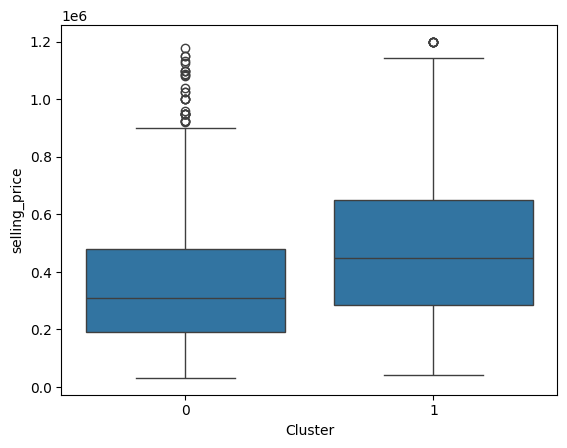

In [23]:
sns.boxplot(x='Cluster', y='selling_price', data=df)

In [24]:
df['Cluster'].value_counts()

Cluster
0    2847
1    2409
Name: count, dtype: int64

Cluster 1 has the highest average selling price (478,024), making it the most expensive cluster, while Cluster 0 has a lower average selling price (347,100).

---

## Hierarchical Clustering 

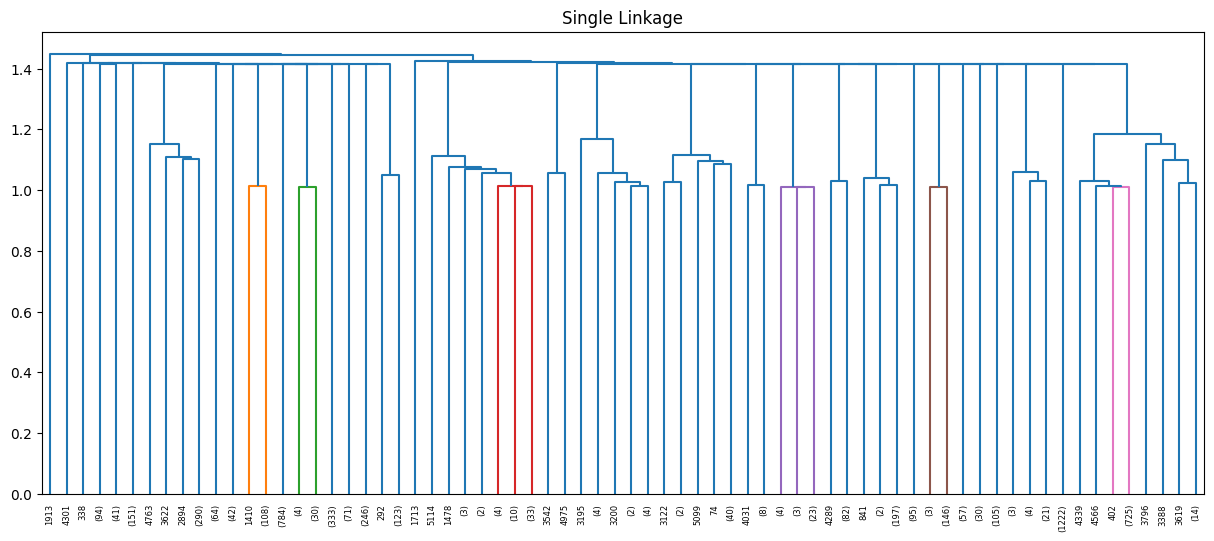

In [25]:
plt.figure(figsize=(15,6))
sch.dendrogram(sch.linkage(df.drop(columns=['selling_price','price_category']), method='single'), truncate_mode='lastp', p=70)
plt.title("Single Linkage")
plt.show()

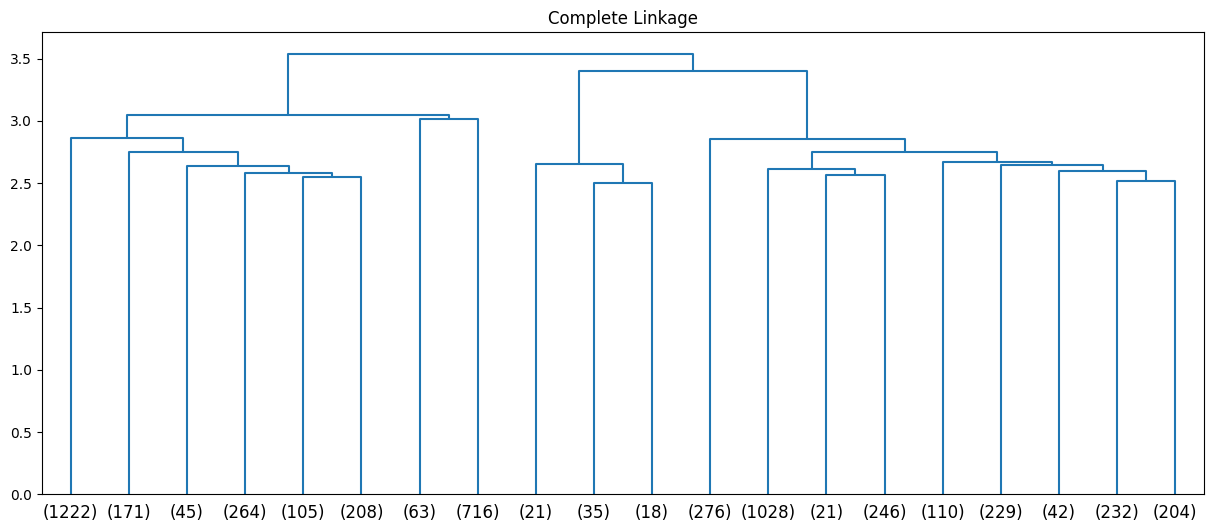

In [26]:
plt.figure(figsize=(15,6))
sch.dendrogram(sch.linkage(df.drop(columns=['selling_price','price_category']), method='complete'), truncate_mode='lastp', p=20)
plt.title("Complete Linkage")
plt.show()

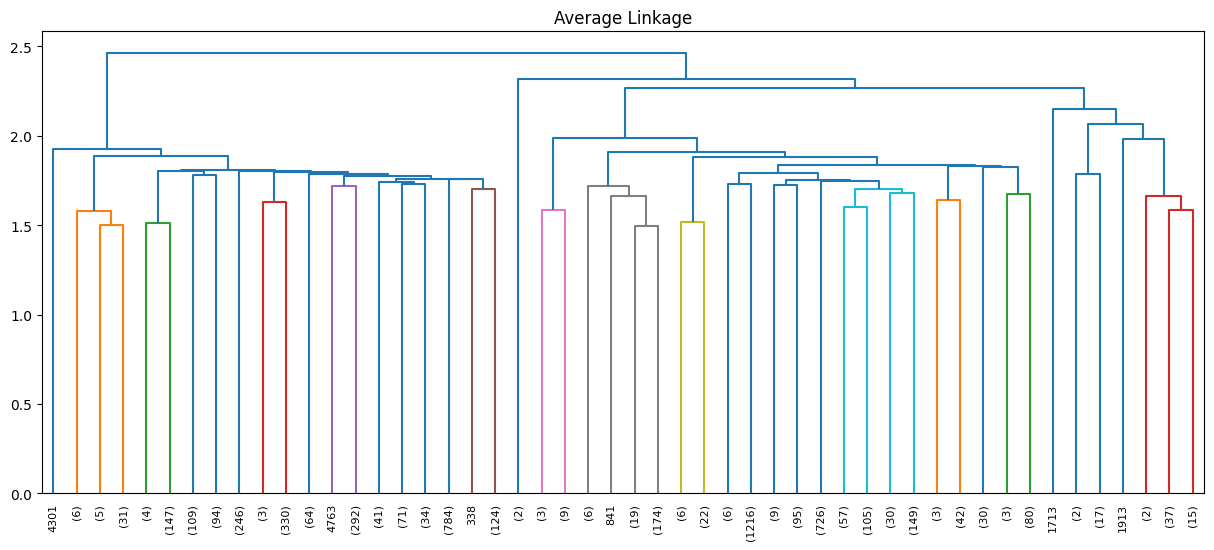

In [27]:
plt.figure(figsize=(15,6))
sch.dendrogram(sch.linkage(df.drop(columns=['selling_price','price_category']), method='average'), truncate_mode='lastp', p=50)
plt.title("Average Linkage")
plt.show()

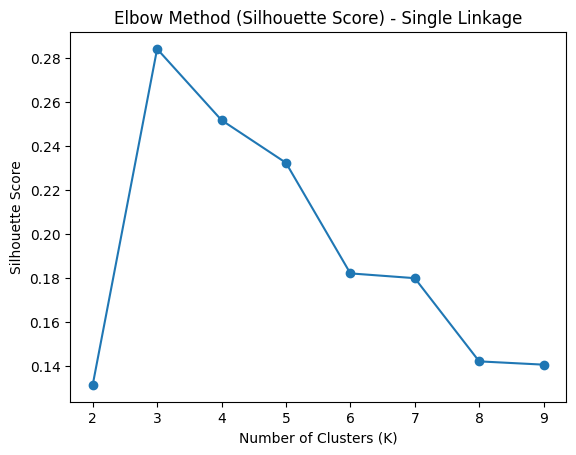

In [28]:
#  Elbow Method

scores = []
K_range = range(2, 10)

X_data = df.drop(columns=['selling_price', 'price_category'])

for k in K_range:
    model = AgglomerativeClustering(n_clusters=k, linkage='single')
    labels = model.fit_predict(X_data)
    
    score = silhouette_score(X_data, labels)
    scores.append(score)

plt.plot(K_range, scores, marker='o')
plt.title('Elbow Method (Silhouette Score) - Single Linkage')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.show()

In [29]:
# Silhouette Score

scores = []

for k in range(2, 10):
    model = AgglomerativeClustering(n_clusters=k, linkage='single')
    Hlabels = model.fit_predict(df.drop(columns=['selling_price','price_category']))
    
    score = silhouette_score(df.drop(columns=['selling_price','price_category']), Hlabels)
    scores.append(score)
    print(f"k={k} -> silhouette = {score}")

k=2 -> silhouette = 0.13139945697419483
k=3 -> silhouette = 0.2840491914194085
k=4 -> silhouette = 0.25168752583759907
k=5 -> silhouette = 0.2323092924397881
k=6 -> silhouette = 0.1820690696541198
k=7 -> silhouette = 0.17990054715230813
k=8 -> silhouette = 0.14209771758438486
k=9 -> silhouette = 0.14060730684410896


In [30]:
print('The best k is : 3')
best_k = 3

model = AgglomerativeClustering(
    n_clusters=best_k,
    
)

Hlabels = model.fit_predict(
    df.drop(columns=['selling_price','price_category'])
)

df['hierarchical_cluster'] = Hlabels
df_without_scaling['hierarchical_cluster'] = Hlabels

The best k is : 3


In [31]:
df['hierarchical_cluster'] = Hlabels
df_without_scaling['hierarchical_cluster'] = Hlabels
df_without_scaling.groupby('hierarchical_cluster').agg({
    'selling_price':'mean',
       'km_driven':'mean',
    'car_age':'mean'
    })

,selling_price,km_driven,car_age
hierarchical_cluster,,,
0,479765.003769,81334.902848,12.029732
1,381280.225909,51338.368858,11.973835
2,304849.269792,57297.361261,13.292852


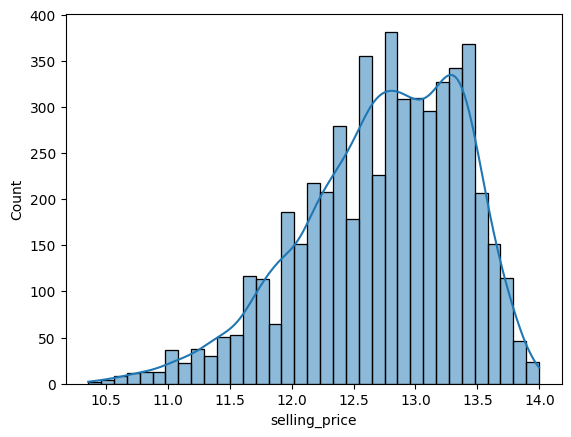

In [32]:
sns.histplot(np.log1p(df['selling_price']), kde=True)
plt.show()

The clustering results reveal three distinct customer segments based on pricing, usage, and vehicle age.

Cluster 0 (Premium) represents the high-end segment, with the highest average selling price (≈479,765), along with relatively high mileage and moderately aged cars.

Cluster 1 (Mid-range) includes vehicles with a average price level (≈381,280), lower mileage compared to the premium segment, and slightly newer cars.

Cluster 2 (Budget) represents the most economical segment, with the lowest average selling price (≈304,849), moderate mileage, and the oldest vehicles on average.

Overall, the segmentation shows a clear relationship between price, car age, and usage, where higher-priced vehicles tend to be newer and more premium-oriented, while lower-priced vehicles are older and more budget-friendly.

---

## Fuzzy Logic Inference System

In [33]:
df_without_scaling['hierarchical_cluster'] = Hlabels


df['market_segment'] = df['hierarchical_cluster'].map({

2:'budget',
1:'mid',
0:'premium'


})
df_without_scaling['market_segment'] = df_without_scaling['hierarchical_cluster'].map({
    2:'budget',
1:'mid',
0:'premium',

})



df_without_scaling['segment_num'] = df_without_scaling['market_segment'].map({
    'budget':2,
    'mid':1,
    'premium':0
}) 

In [34]:
car_age = ctrl.Antecedent(np.arange(df_without_scaling['car_age'].min(), df_without_scaling['car_age'].max(), 1), 'car_age')
power_density = ctrl.Antecedent(np.linspace(df_without_scaling['power_density'].min(), df_without_scaling['power_density'].max(), 100),'power_density')
torque_value = ctrl.Antecedent(np.linspace(df_without_scaling['torque_value'].min(), df_without_scaling['torque_value'].max(), 100),'torque_value')
max_power_by_bhp = ctrl.Antecedent(np.linspace(df_without_scaling['max_power by bhp'].min(), df_without_scaling['max_power by bhp'].max(), 100),'max_power by bhp')
segment_num = ctrl.Antecedent(np.arange(0, 3, 1), 'segment_num')
selling_price = ctrl.Consequent(np.linspace(df_without_scaling['selling_price'].min(), df_without_scaling['selling_price'].max(), 100),'selling_price')

In [35]:
segment_num['premium'] = fuzz.trimf(segment_num.universe,[0,0,1])
segment_num['mid']     = fuzz.trimf(segment_num.universe,[0,1,2])
segment_num['budget']  = fuzz.trimf(segment_num.universe,[1,2,2])


min_v = car_age.universe.min()
max_v = car_age.universe.max()
mid_v = (min_v + max_v) / 2

car_age['new']    = fuzz.trimf(car_age.universe, [min_v, min_v, mid_v])
car_age['medium'] = fuzz.trimf(car_age.universe, [min_v, mid_v, max_v])
car_age['old']    = fuzz.trimf(car_age.universe, [mid_v, max_v, max_v])


min_v = power_density.universe.min()
max_v = power_density.universe.max()
mid_v = (min_v + max_v) / 2

power_density['low']    = fuzz.trimf(power_density.universe, [min_v, min_v, mid_v])
power_density['medium'] = fuzz.trimf(power_density.universe, [min_v, mid_v, max_v])
power_density['high']   = fuzz.trimf(power_density.universe, [mid_v, max_v, max_v])


min_v = torque_value.universe.min()
max_v = torque_value.universe.max()
mid_v = (min_v + max_v) / 2

torque_value['low']    = fuzz.trimf(torque_value.universe, [min_v, min_v, mid_v])
torque_value['medium'] = fuzz.trimf(torque_value.universe, [min_v, mid_v, max_v])
torque_value['high']   = fuzz.trimf(torque_value.universe, [mid_v, max_v, max_v])


min_v = max_power_by_bhp.universe.min()
max_v = max_power_by_bhp.universe.max()
mid_v = (min_v + max_v) / 2

max_power_by_bhp['low']    = fuzz.trimf(max_power_by_bhp.universe, [min_v, min_v, mid_v])
max_power_by_bhp['medium'] = fuzz.trimf(max_power_by_bhp.universe, [min_v, mid_v, max_v])
max_power_by_bhp['high']   = fuzz.trimf(max_power_by_bhp.universe, [mid_v, max_v, max_v])




q1 = df_without_scaling['selling_price'].quantile(0.33)
q2 = df_without_scaling['selling_price'].quantile(0.66)

min_v = df_without_scaling['selling_price'].min()
max_v = df_without_scaling['selling_price'].max()

selling_price['low'] = fuzz.trimf(
    selling_price.universe,
    [min_v, min_v, q1]
)

selling_price['medium'] = fuzz.trimf(
    selling_price.universe,
    [min_v, q1, q2]
)

selling_price['high'] = fuzz.trimf(
    selling_price.universe,
    [q1, q2, max_v]
)

In [36]:
rule1 = ctrl.Rule(
    car_age['old'],
    selling_price['low']
)

rule2 = ctrl.Rule(
    torque_value['low'] & power_density['low'],
    selling_price['low']
)

rule3 = ctrl.Rule(
    car_age['old'] & max_power_by_bhp['low'],
    selling_price['low']
)

rule4 = ctrl.Rule(
    segment_num['budget'],
    selling_price['low']
)

rule5 = ctrl.Rule(
    segment_num['budget'] & car_age['old'],
    selling_price['low']
)

rule6 = ctrl.Rule(
    max_power_by_bhp['low'] & torque_value['low'],
    selling_price['low']
)


rule7 = ctrl.Rule(
    car_age['medium'],
    selling_price['medium']
)

rule8 = ctrl.Rule(
    max_power_by_bhp['medium'],
    selling_price['medium']
)

rule9 = ctrl.Rule(
    

    segment_num['mid'], 
    

    selling_price['medium']
)

rule10 = ctrl.Rule(
    
    segment_num['mid'] & car_age['new'],
    selling_price['medium']
)

rule11 = ctrl.Rule(
    car_age['old'] & torque_value['high'],
    selling_price['medium']
)

rule12 = ctrl.Rule(
    segment_num['mid'] & max_power_by_bhp['low'],
    selling_price['medium']
)


rule13 = ctrl.Rule(
    car_age['new'] & max_power_by_bhp['high'],
    selling_price['high']
)

rule14 = ctrl.Rule(
    torque_value['high'] & power_density['high'],
    selling_price['high']
)

rule15 = ctrl.Rule(
    car_age['new'] & max_power_by_bhp['high'] & torque_value['high'],
    selling_price['high']
)

rule16 = ctrl.Rule(
    segment_num['premium'] & car_age['new'],
    selling_price['high']
)

rule17 = ctrl.Rule(
    segment_num['premium'] & torque_value['high'],
    selling_price['high']
)

rule18 = ctrl.Rule(
    segment_num['mid'] & max_power_by_bhp['high'],
    selling_price['high']
)
rule19 = ctrl.Rule(
    segment_num['budget'] & car_age['old'] & max_power_by_bhp['low'],
    selling_price['low']
)
rule20 = ctrl.Rule(
    segment_num['premium'] &
    max_power_by_bhp['high'] &
    torque_value['high'],
    selling_price['high']
)

In [37]:
warnings.filterwarnings('ignore', category=UserWarning)

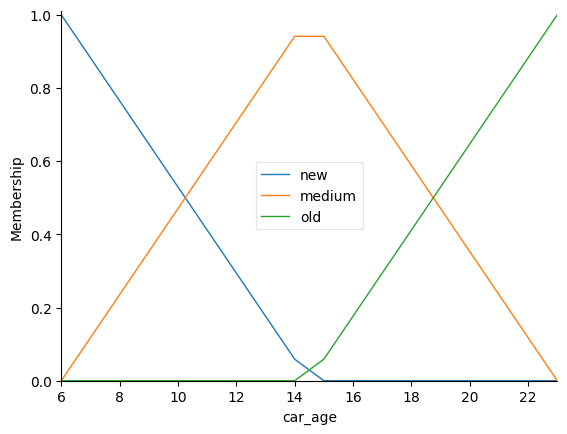

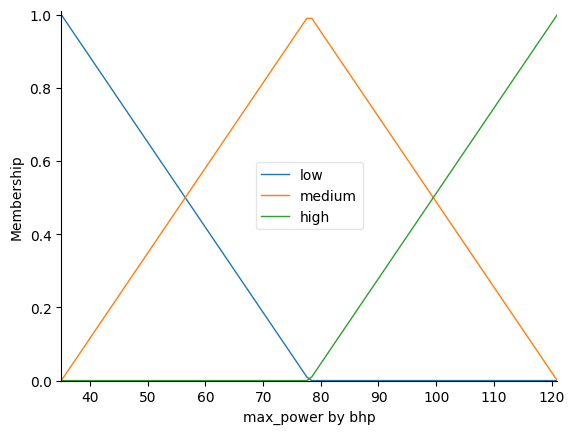

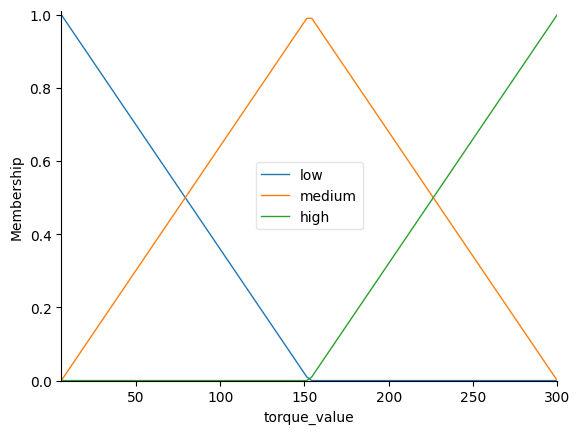

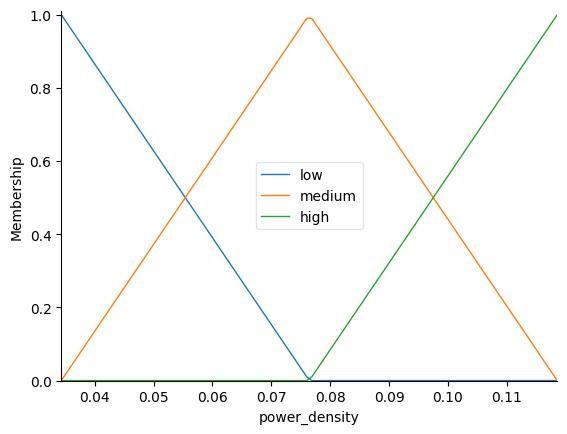

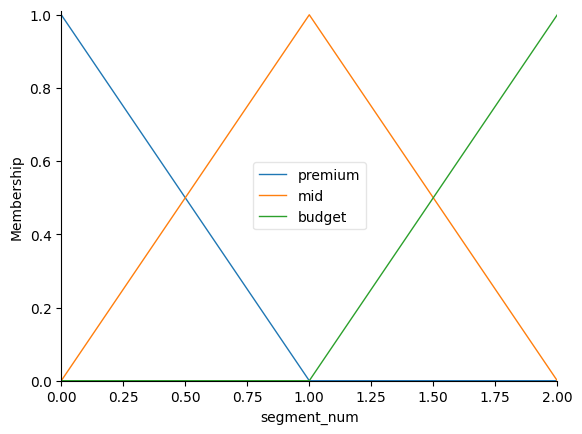

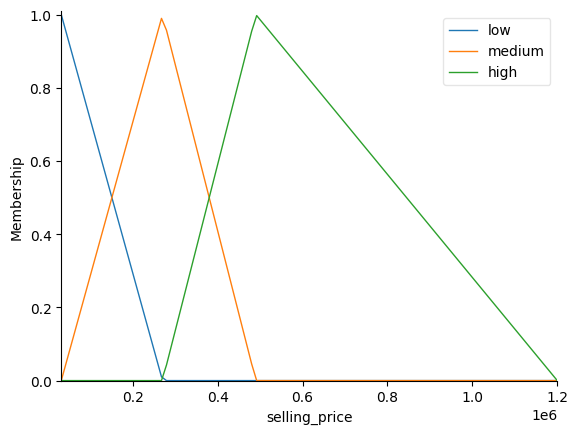

In [38]:
car_age.view()
max_power_by_bhp.view()
torque_value.view()
power_density.view()    
segment_num.view()
selling_price.view()

In [39]:
sprinkler_system = ctrl.ControlSystem([rule1, rule2, rule3, rule4,rule5, rule6, rule7, rule8, rule9, rule10, rule11 , rule12, rule13, rule14, rule15, rule16, rule17, rule18, rule19, rule20])
sprinkler_simulator = ctrl.ControlSystemSimulation(sprinkler_system)

502195.0475299811
Low: 0.0 %
Medium: 0.0 %
High: 98.28238767183365 %


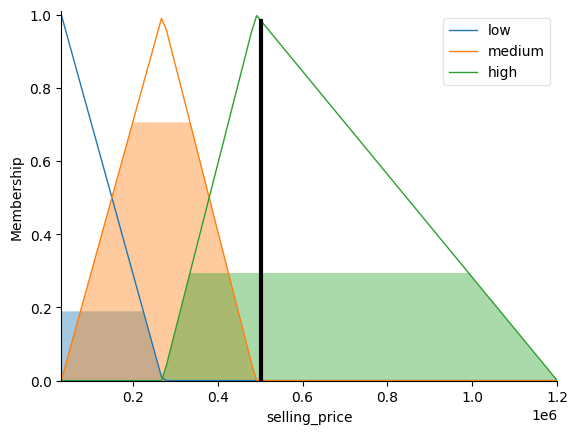

In [40]:
sprinkler_simulator.input['car_age'] = 12
sprinkler_simulator.input['power_density'] = 0.065
sprinkler_simulator.input['torque_value'] = 125
sprinkler_simulator.input['max_power by bhp'] = 50
sprinkler_simulator.input['segment_num'] = 0

sprinkler_simulator.compute()


selling_price.view(sim=sprinkler_simulator)


price_value = sprinkler_simulator.output['selling_price']

print( price_value )


low_degree = fuzz.interp_membership(
    selling_price.universe,
    selling_price['low'].mf,
    price_value
)

medium_degree = fuzz.interp_membership(
    selling_price.universe,
    selling_price['medium'].mf,
    price_value
)

high_degree = fuzz.interp_membership(
    selling_price.universe,
    selling_price['high'].mf,
    price_value
)

print("Low:", low_degree * 100, "%")
print("Medium:", medium_degree * 100, "%")
print("High:", high_degree * 100, "%")

In [41]:
results = []

for i in range(10):
    row = df_without_scaling.iloc[i]

    sprinkler_simulator.input['car_age'] = row['car_age']
    sprinkler_simulator.input['power_density'] = row['power_density']
    sprinkler_simulator.input['torque_value'] = row['torque_value']
    sprinkler_simulator.input['max_power by bhp'] = row['max_power by bhp']
    sprinkler_simulator.input['segment_num'] = row['segment_num']

    sprinkler_simulator.compute()

    pred = sprinkler_simulator.output['selling_price']
    actual = row['selling_price']

    results.append([i, f"{actual:.0f}", f"{pred:.0f}", f"{abs(actual-pred):.0f}"])
    print(f"the actual price is ({actual:.0f}) , pred price is ({pred:.0f}) and difference is ({abs(actual-pred):.0f})")
    

the actual price is (450000) , pred price is (496858) and difference is (46858)
the actual price is (370000) , pred price is (545760) and difference is (175760)
the actual price is (158000) , pred price is (240905) and difference is (82905)
the actual price is (225000) , pred price is (254958) and difference is (29958)
the actual price is (130000) , pred price is (222034) and difference is (92034)
the actual price is (440000) , pred price is (377841) and difference is (62159)
the actual price is (96000) , pred price is (214668) and difference is (118668)
the actual price is (350000) , pred price is (406312) and difference is (56312)
the actual price is (200000) , pred price is (451086) and difference is (251086)
the actual price is (500000) , pred price is (545532) and difference is (45532)


---

## Genetic Algorithm Optimization 

In [42]:
X = df.drop(['selling_price','hierarchical_cluster','market_segment','price_category','Cluster'], axis=1)
y = df['selling_price']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)


lr = sklearn.linear_model.LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
r2 = r2_score(y_test, y_pred)
print("R2 Score :",r2)
print('mse',sklearn.metrics.mean_squared_error(y_test, y_pred))
print('mae',sklearn.metrics.mean_absolute_error(y_test, y_pred))

R2 Score : 0.8032566302634094
mse 10543059154.34415
mae 79043.78460099985


In [43]:
random.seed(42)
np.random.seed(42)

target_col = 'selling_price'

X = df.drop(['selling_price','hierarchical_cluster','market_segment','price_category','Cluster'], axis=1)
y = df[target_col]

feature_names = X.columns.tolist()
n_features = len(feature_names)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Parameters

population_size = 40
generations = 20
mutation_probability = 0.10

# Create 


def create_individual():
    return [random.randint(0,1) for _ in range(n_features)]

# Fitness Function


def fitness(individual):


    selected = [i for i in range(n_features) if individual[i] == 1]

    if len(selected) == 0:
        return -9999

    cols = [feature_names[i] for i in selected]

    Xtr = X_train[cols]
    Xts = X_test[cols]

    model = LinearRegression()
    model.fit(Xtr, y_train)
    pred = model.predict(Xts)

    score = r2_score(y_test, pred)

    return score

# Parent Selection

def select_parent(population):
    tournament = random.sample(population, 3)
    return max(tournament, key=fitness)

# Crossover

def crossover(parent1, parent2):

    point = random.randint(1, n_features-1)

    child = parent1[:point] + parent2[point:]

    return child

# Mutation

def mutate(individual):

    for i in range(n_features):

        if random.random() < mutation_probability:
            individual[i] = 1 - individual[i]

    return individual

# Main GA ###########################################################################################

def genetic_algorithm():

    population = [create_individual() for _ in range(population_size)]

    for generation in range(generations):

        population = sorted(population, key=fitness, reverse=True)

        best = population[0]
        best_score = fitness(best)

        print(f"Generation {generation+1}")
        print("Best Chromosome:", best)
        print("Best R2:", round(best_score,4))
        print("------------")

        new_population = []

        for _ in range(population_size):

            parent1 = select_parent(population)
            parent2 = select_parent(population)

            child = crossover(parent1, parent2)
            child = mutate(child)

            new_population.append(child)

        population = new_population

    
    best = max(population, key=fitness)
    best_score = fitness(best)

    selected_features = [
        feature_names[i]
        for i in range(n_features)
        if best[i] == 1
    ]

    print("\nFinal Best Solution")
    print("Best Chromosome:", best)
    print("Selected Features:", selected_features)
    print("Best R2 Score:", round(best_score,4))

genetic_algorithm()
Selected_Features =  ['km_driven', 'seats', 'mileage_value', 'engine by CC', 'max_power by bhp', 'torque_value', 'car_age', 'power_density', 'km_per_year', 'fuel_Diesel', 'fuel_LPG', 'fuel_Petrol', 'owner_Fourth & Above Owner', 'owner_Second Owner', 'owner_Third Owner', 'brand_name_Datsun', 'brand_name_Fiat', 'brand_name_Ford', 'brand_name_Honda', 'brand_name_Hyundai', 'brand_name_Mahindra', 'brand_name_Maruti', 'brand_name_Nissan', 'brand_name_Toyota', 'transmission_Manual']



Generation 1
Best Chromosome: [1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1]
Best R2: 0.8043
------------
Generation 2
Best Chromosome: [1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1]
Best R2: 0.7986
------------
Generation 3
Best Chromosome: [0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1]
Best R2: 0.8035
------------
Generation 4
Best Chromosome: [1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1]
Best R2: 0.8055
------------
Generation 5
Best Chromosome: [1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1]
Best R2: 0.8045
------------
Generation 6
Best Chromosome: [1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1]
Best R2: 0.8051
------------
Generation 7
Best Chromosome

In [ ]:
# systeeemm 

best_features = Selected_Features  #from el genticcccccc 

final_model = LinearRegression()
final_model.fit(X_train[best_features], y_train)

def system(row_index):

    print("="*50)
    print(" CAR  SYSTEM")
    print("="*50)



    row = df_without_scaling.iloc[row_index].copy()
    row_scaled = df.iloc[row_index].copy()
    actual_price = row['selling_price']

    print(f"Selected Row Index : {row_index}")
    print(f"Actual Selling Price : {actual_price:,.0f}")
    print("-"*50)

    cluster_result = row_scaled['Cluster']
    print("KMedoids Cluster :", cluster_result)

    hier_cluster = row['hierarchical_cluster']
    market_segment = row['market_segment']

    print("Hierarchical Cluster :", hier_cluster)
    print("Market Segment :", market_segment)
    
    sprinkler_simulator.input['car_age'] = row['car_age']
    sprinkler_simulator.input['power_density'] = row['power_density']
    sprinkler_simulator.input['torque_value'] = row['torque_value']
    sprinkler_simulator.input['max_power by bhp'] = row['max_power by bhp']
    sprinkler_simulator.input['segment_num'] = row['segment_num']

    sprinkler_simulator.compute()

    fuzzy_price = sprinkler_simulator.output['selling_price']

    print("Fuzzy Predicted Price :", round(fuzzy_price,2))


   
    test_row = row_scaled[best_features].values.reshape(1,-1)

    ga_price = final_model.predict(test_row)[0]

    print("GA Regression Price :", round(ga_price,2))


    final_price = (fuzzy_price + ga_price) / 2

    error = abs(actual_price - final_price)

    print("-"*50)
    print("Final Recommended Price :", round(final_price,2))
    print("Actual Price            :", round(actual_price,2))
    print("Difference              :", round(error,2))
    print("="*50)

In [45]:
for i in range(100):
    row = df_without_scaling.iloc[i]
    system(i)

 CAR  SYSTEM
Selected Row Index : 0
Actual Selling Price : 450,000
--------------------------------------------------
KMedoids Cluster : 1
Hierarchical Cluster : 0
Market Segment : premium
Fuzzy Predicted Price : 496858.48
GA Regression Price : 445735.63
--------------------------------------------------
Final Recommended Price : 471297.06
Actual Price            : 450000.0
Difference              : 21297.06
 CAR  SYSTEM
Selected Row Index : 1
Actual Selling Price : 370,000
--------------------------------------------------
KMedoids Cluster : 1
Hierarchical Cluster : 0
Market Segment : premium
Fuzzy Predicted Price : 545759.99
GA Regression Price : 481259.65
--------------------------------------------------
Final Recommended Price : 513509.82
Actual Price            : 370000.0
Difference              : 143509.82
 CAR  SYSTEM
Selected Row Index : 2
Actual Selling Price : 158,000
--------------------------------------------------
KMedoids Cluster : 0
Hierarchical Cluster : 1
Market Segm